# 05 - TF-IDF + Logistic Regression Demonstration

This notebook demonstrates the traditional supervised machine-learning
component of the sentiment-analysis research framework.

The approach combines Term Frequency-Inverse Document Frequency (TF-IDF)
text representation with Logistic Regression classification.

TF-IDF converts textual input into numerical features based on the
importance of terms within the document collection. Logistic Regression
then uses these features to classify sentiment.

The demonstration uses synthetic data only.

The results produced in this notebook demonstrate technical
implementation and must not be interpreted as empirical findings from
Reddit users.

Final empirical evaluation would require an appropriately authorised
and ethically approved research dataset with manually labelled
sentiment categories.

In [76]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.tfidf_logistic_regression import (
    TfidfLogisticRegressionModel,
    create_model,
    train_model,
    predict,
)

In [77]:
DATA_PATH = PROJECT_ROOT / "data" / "sample_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (9, 3)


,text,game,sentiment
0,The pity system is really helpful and makes pu...,Genshin Impact,Positive
1,The banner rates feel terrible and I spent far...,Genshin Impact,Negative
2,I saved enough primogems for the next character.,Genshin Impact,Neutral
3,I actually like the pity system because I know...,Honkai: Star Rail,Positive
4,The cost of pulls is ridiculous for free to pl...,Honkai: Star Rail,Negative


In [78]:
print(df.columns.tolist())

['text', 'game', 'sentiment']


In [79]:
df["sentiment"].value_counts()

sentiment
Positive    3
Negative    3
Neutral     3
Name: count, dtype: int64

In [80]:
df["sentiment"].value_counts(normalize=True)

sentiment
Positive    0.333333
Negative    0.333333
Neutral     0.333333
Name: proportion, dtype: float64

### Class Distribution

The class distribution is inspected before model training because
imbalanced classes can affect supervised classification performance.

The final research dataset would therefore report class distribution
alongside precision, recall and macro-F1.

In [81]:
texts = df["text"].astype(str).tolist()
labels = df["sentiment"].astype(str).tolist()

print(f"Number of texts: {len(texts)}")
print(f"Number of labels: {len(labels)}")

assert len(texts) == len(labels)

print("Text and label lengths match.")

Number of texts: 9
Number of labels: 9
Text and label lengths match.


In [82]:
model = create_model()

print("TF-IDF + Logistic Regression model created successfully.")

TF-IDF + Logistic Regression model created successfully.


In [83]:
model.pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True

In [84]:
trained_model = train_model(
    texts,
    labels,
)

print("Model training completed.")

Model training completed.


In [85]:
ngram_range=(1, 2)

tfidf = trained_model.pipeline.named_steps["tfidf"]

feature_names = tfidf.get_feature_names_out()

print(f"Number of TF-IDF features: {len(feature_names)}")

feature_names[:50]

Number of TF-IDF features: 119


array(['actually', 'actually like', 'am', 'am guaranteed', 'am waiting',
       'and', 'and makes', 'and spent', 'are', 'banner', 'banner before',
       'banner feel', 'banner rates', 'banner starts', 'because',
       'because know', 'before', 'before spending', 'character', 'cost',
       'cost of', 'enough', 'enough primogems', 'expensive',
       'expensive the', 'fairer', 'far', 'far too', 'feel', 'feel much',
       'feel terrible', 'for', 'for free', 'for the', 'free', 'free to',
       'guaranteed', 'hate', 'hate how', 'helpful', 'helpful and', 'how',
       'how expensive', 'is', 'is really', 'is ridiculous', 'know',
       'know when', 'less', 'less stressful'], dtype=object)

In [86]:
classifier = trained_model.pipeline.named_steps["classifier"]

print(classifier)

print("Classes:")
print(classifier.classes_)

LogisticRegression(max_iter=1000, random_state=42)
Classes:
['Negative' 'Neutral' 'Positive']


In [87]:
predictions = predict(
    trained_model,
    texts,
)

predictions[:10]

['Positive',
 'Negative',
 'Neutral',
 'Positive',
 'Negative',
 'Neutral',
 'Positive',
 'Negative',
 'Neutral']

In [88]:
prediction_output = pd.DataFrame({
    "text": texts,
    "true_label": labels,
    "predicted_label": predictions,
})

prediction_output.head(10)

,text,true_label,predicted_label
0,The pity system is really helpful and makes pu...,Positive,Positive
1,The banner rates feel terrible and I spent far...,Negative,Negative
2,I saved enough primogems for the next character.,Neutral,Neutral
3,I actually like the pity system because I know...,Positive,Positive
4,The cost of pulls is ridiculous for free to pl...,Negative,Negative
5,The new banner starts next week.,Neutral,Neutral
6,The pity system makes the banner feel much fai...,Positive,Positive
7,I hate how expensive the pulls are.,Negative,Negative
8,I am waiting to see the next banner before spe...,Neutral,Neutral


In [89]:
prediction_output[
    "predicted_label"
].value_counts()

predicted_label
Positive    3
Negative    3
Neutral     3
Name: count, dtype: int64

In [90]:
from src.evaluation import (
    calculate_metrics,
    create_confusion_matrix,
    generate_classification_report,
)

metrics = calculate_metrics(
    labels,
    predictions,
)

metrics

{'precision_macro': 1.0, 'recall_macro': 1.0, 'macro_f1': 1.0}

In [91]:
metrics_df = pd.DataFrame({
    "Metric": [
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
    ],
    "Score": [
        metrics["precision_macro"],
        metrics["recall_macro"],
        metrics["macro_f1"],
    ],
})

metrics_df

,Metric,Score
0,Macro Precision,1.0
1,Macro Recall,1.0
2,Macro F1,1.0


In [92]:
labels_order = [
    "Negative",
    "Neutral",
    "Positive",
]

confusion_df = create_confusion_matrix(
    labels,
    predictions,
    labels=labels_order,
)

confusion_df

,Negative,Neutral,Positive
Negative,3,0,0
Neutral,0,3,0
Positive,0,0,3


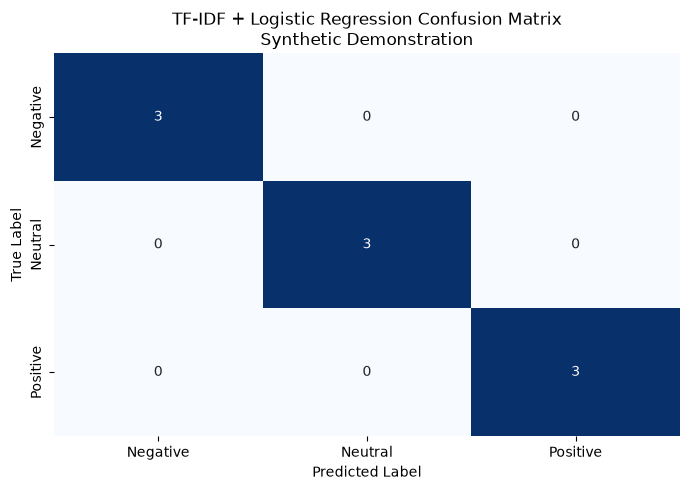

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)

plt.title(
    "TF-IDF + Logistic Regression Confusion Matrix\n"
    "Synthetic Demonstration"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [94]:
report = generate_classification_report(
    labels,
    predictions,
)

print(report)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         3
     Neutral       1.00      1.00      1.00         3
    Positive       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



## Important Methodological Note

The demonstration above trains and evaluates the model using the
synthetic demonstration dataset.

This is appropriate for verifying that the implementation functions
correctly, but it does not provide a valid estimate of performance on
the proposed Reddit research population.

For the final empirical study, the dataset would need to be collected
through an appropriately authorised and ethically approved process.

The manually labelled data would then be divided into appropriate
training, validation and test subsets. The test set would remain
separate from model training and would be used for the final evaluation.

The resulting precision, recall and macro-F1 scores would then be
reported as empirical model-performance results.

## Role of the Model in the Research Framework

TF-IDF + Logistic Regression provides the traditional supervised
machine-learning component of the model comparison.

It is intentionally positioned between the simpler VADER baseline and
the more computationally complex transformer-based approach.

The comparison therefore provides three levels of modelling:

1. VADER — rule-based baseline
2. TF-IDF + Logistic Regression — traditional supervised machine learning
3. DistilBERT — transformer-based approach

This structure allows the research to investigate whether increased
model complexity produces improved sentiment-classification performance.

## Limitations of the Demonstration

The demonstration has several limitations.

First, the dataset used is synthetic and therefore does not represent
actual Reddit users.

Second, the model is trained and evaluated on the same demonstration
data. This can result in overly optimistic performance and does not
represent a valid empirical evaluation procedure.

Third, the demonstration dataset is substantially smaller than the
proposed research dataset.

Fourth, the model has not been evaluated against the final manually
labelled research data.

Consequently, the performance metrics produced here are implementation
checks rather than empirical findings.

## Conclusion

This notebook demonstrates the implementation of the traditional
supervised machine-learning component of the proposed research
framework.

The TF-IDF + Logistic Regression pipeline successfully:

- converts textual input into TF-IDF features;
- considers unigram and bigram representations;
- trains a Logistic Regression classifier;
- generates sentiment predictions;
- calculates macro-averaged evaluation metrics; and
- produces a confusion matrix and classification report.

The demonstration confirms that the technical pipeline can be
executed using the project's Python implementation.

However, the demonstration uses synthetic data and therefore does not
constitute empirical evidence about sentiment expressed by Reddit
users.

The final empirical model comparison remains dependent on ethical
approval, authorised data collection and evaluation using an
appropriately labelled and held-out research dataset.